In [3]:
!pip install loguru

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/

   -------------------- ------------------- 1/2 [loguru]
   ---------------------------------------- 2/2 [loguru]



{'topic': '麻雀', 'poem': '**《咏麻雀》**\n\n檐下啾啾噪晚晴，\n蓬蒿深处觅残羹。\n身微未敢凌云志，\n却伴人间烟火生。', 'ci_poem': '以下是关于“麻雀”的中文词汇，按不同类别整理：\n\n### 1. 基础名称与别称\n*   **麻雀** (má què)：最通用的名称。\n*   **家雀** (jiā què)：因常栖息于人类居住地而得名。\n*   **老家贼** (lǎo jiā zéi)：北方方言中的俗称，略带调侃意味，指其偷吃粮食。\n*   **宾雀** (bīn què)：古称之一。\n*   **瓦雀** (wǎ què)：因常在屋瓦间活动而得名。\n\n### 2. 生物特征与行为\n*   **啁啾** (zhōu jiū)：形容麻雀细小、密集的叫声。\n*   **叽喳** (jī zhā)：拟声词，形容麻雀吵闹的声音。\n*   **群居** (qún jū)：麻雀喜欢成群活动。\n*   **杂食** (zá shí)：既吃谷物也吃昆虫。\n*   **跳跃** (tiào yuè)：麻雀在地面移动的主要方式（非行走）。\n*   **褐斑** (hè bān)：描述其羽毛颜色多为褐色并带有斑点。\n\n### 3. 文化与成语/俗语\n*   **麻雀虽小，五脏俱全**：比喻事物体积或规模虽小，但内容或结构却很完整。\n*   **为渊驱鱼，为丛驱雀**：比喻不善团结人，把可以依靠的力量赶到对方去。\n*   **门可罗雀**：形容门庭冷落，宾客稀少。（注：此处“雀”泛指鸟类，但常与麻雀意象关联）\n*   **鸦雀无声**：连乌鸦和麻雀的声音都没有，形容非常安静。\n*   **螳螂捕蝉，黄雀在后**：比喻只顾眼前利益而不顾后患。（注：“黄雀”是麻雀的近亲，常被一同提及）\n\n### 4. 相关引申义\n*   **麻友** (má yǒu)：打麻将的朋友（因麻将牌中有一张牌叫“麻雀”或“鸟”，且麻将本身在部分地区被称为“麻雀”）。\n*   **雀屏** (què píng)：古代选婿的典故，虽多指孔雀，但有时文学作品中会泛化使用。\n\n### 5. 科学分类相关\n*   **雀科** (Què kē)：麻雀所属的鸟类科别。\n*   **树麻雀** (Shù má què)：

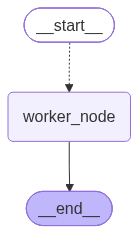

In [11]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from loguru import logger
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Sequence
from langgraph.types import Send

load_dotenv(override=True, verbose=True)

CONTENT_TYPES = ["poem", "joke", "ci_poem"]

# 初始化模型
model = init_chat_model(
    "qwen3.7-plus-2026-05-26",
    model_provider="openai",
    temperature=0.5,
    max_tokens=1024,
    timeout=60,
    max_retries=3,
    base_url=os.getenv("DASHSCOPE_API_URL"),
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    extra_body={
        "thinking": {
            "type": "disabled"
            }
    }
)

# 1. 定义状态
# 1.1 全局状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str

# 1.2 私有状态
class workerState(TypedDict):
    content_type: Literal["poem", "joke", "ci_poem"]
    prompt: str

# 1.3 输入状态
class inputState(TypedDict):
    topic: str

# 1.4 输出状态
class outputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str

# 2. 定义节点
def worker_node(state: workerState) -> outputState:
    '''
    工作节点
    '''
    content_type = state['content_type']
    prompt = state['prompt']
    
    content = model.invoke([HumanMessage(content=prompt)]).content
    return {
        content_type: content
    }

# 3. 定义动态分支的路由
def router(state: inputState) -> Sequence[Send]:
    '''
    动态分支路由
    '''
    
    router_prompt = "请生成关于 {} 的 {}"
    english2Chinese = {
        "poem": "七言绝句",
        "joke": "笑话",
        "ci_poem": "中文词"
    }
    topic = state['topic']
    return [
        Send("worker_node",
        {
            "content_type": content_type,
            "prompt": router_prompt.format(topic, english2Chinese[content_type])
        })
    for content_type in CONTENT_TYPES]

# 4. 构建图
builder = StateGraph(state_schema=OverAllState, input_state=inputState, output_state=outputState)
builder.add_node("worker_node", worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"]
)

builder.add_edge("worker_node", END)

graph = builder.compile()

result = graph.invoke({"topic": "麻雀"})
print(result)

from IPython.display import display
display(graph)
